## Methodology

In this project, data was collected using the Riot Games API from leaderboard players (Challenger, Grandmaster, and Master tiers).

Each observation corresponds to a player’s performance in a single ranked match.

The analysis consists of three main steps:
1. Data collection and preprocessing
2. Exploratory Data Analysis (EDA)
3. Statistical hypothesis testing

EDA is used to understand distributions and relationships between variables such as KDA, damage, and vision score.

Hypothesis testing is used to determine whether observed differences are statistically significant.

## Hypotheses

H0: The mean vision score is the same for winning and losing matches.  
H1: The mean vision score is higher in winning matches.

H0: Match outcome is independent of player tier.  
H1: Match outcome depends on player tier.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency

In [27]:
df = pd.read_csv("../data/processed/lol_ranked_dataset.csv")
df.shape

if "game_duration_min" not in df.columns:
    if "game_duration" in df.columns:
        df["game_duration_min"] = df["game_duration"] / 60

In [28]:
df.head()

,match_id,puuid,tier,win,kills,deaths,assists,kda,champion,role,...,goldEarned,champLevel,cs_total,gameDuration,gameCreation,queueId,gameMode,cs_per_min,damage_per_min,vision_per_min
0,EUW1_7818779633,V1JUuzxBEEwhyjjRBVctPiFxd-O68M4GNaoV7qvyWxSSLf...,GRANDMASTER,0,5,6,4,1.500000,Gnar,TOP,...,13732,17,278,1933,1776024753339,420,CLASSIC,8.629074,906.549405,1.272633
1,EUW1_7818779633,uNtXG0rwGgQqUxwiNsaGT5YC3i5U1jrYz69btGEvqWF-f8...,CHALLENGER,0,4,7,6,1.428571,Karthus,JUNGLE,...,14025,17,253,1933,1776024753339,420,CLASSIC,7.853078,985.483704,0.962235
2,EUW1_7818779633,9kkr7CzKAQdDIAZ6pU8dFQSud6EgaqSSOslOVfVa4BAMn5...,CHALLENGER,0,5,6,3,1.333333,Akshan,MIDDLE,...,14365,16,284,1933,1776024753339,420,CLASSIC,8.815313,782.296948,1.179514
3,EUW1_7818779633,vzC0-V3SjwcTe7sr4dN3y7H1yAR6nXtGRHRTDIVWO6vY4x...,CHALLENGER,0,3,8,4,0.875000,Varus,BOTTOM,...,12316,15,254,1933,1776024753339,420,CLASSIC,7.884118,595.157786,0.186239
4,EUW1_7818779633,bjRVLRw4wT7fjT3gas500bJdz7yoSyLc863WOiBxULtviO...,GRANDMASTER,0,0,6,13,2.166667,Bard,UTILITY,...,8732,12,27,1933,1776024753339,420,CLASSIC,0.838076,425.866529,4.066218


In [29]:
df.isnull().sum()

match_id           0
puuid              0
tier              10
win                0
kills              0
deaths             0
assists            0
kda                0
champion           0
role               0
visionScore        0
damage             0
damageTaken        0
goldEarned         0
champLevel         0
cs_total           0
gameDuration       0
gameCreation       0
queueId            0
gameMode           0
cs_per_min         0
damage_per_min     0
vision_per_min     0
dtype: int64

In [30]:
df.describe()

,win,kills,deaths,assists,kda,visionScore,damage,damageTaken,goldEarned,champLevel,cs_total,gameDuration,gameCreation,queueId,cs_per_min,damage_per_min,vision_per_min
count,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2.980000e+03,2980.0,2980.000000,2980.000000,2980.000000
mean,0.500000,5.317785,5.331544,8.021141,3.855476,36.074161,20157.190604,24936.998658,11278.012752,14.208725,169.788591,1583.486577,1.775979e+12,420.0,6.434976,738.055703,1.321604
std,0.500084,4.202097,3.017485,5.989744,4.308041,30.604520,11732.663376,11558.170464,3916.667868,2.856896,88.044876,389.733103,1.534686e+08,0.0,2.935295,342.750654,0.978313
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,519.000000,1.000000,0.000000,74.000000,1.775340e+12,420.0,0.000000,0.000000,0.000000
25%,0.000000,2.000000,3.000000,4.000000,1.262500,17.000000,11199.250000,16904.000000,8499.750000,12.000000,120.750000,1348.000000,1.775919e+12,420.0,5.826596,481.713364,0.704941
50%,0.500000,4.000000,5.000000,7.000000,2.400000,26.000000,18130.500000,23354.500000,10977.000000,14.000000,188.000000,1598.000000,1.776019e+12,420.0,7.422970,701.688262,0.951821
75%,1.000000,8.000000,7.000000,11.000000,4.666667,41.000000,26733.500000,31221.250000,13778.500000,16.000000,233.000000,1828.000000,1.776092e+12,420.0,8.429152,942.704057,1.413822
max,1.000000,27.000000,18.000000,37.000000,36.000000,193.000000,83009.000000,102930.000000,27650.000000,20.000000,404.000000,2604.000000,1.776154e+12,420.0,11.534626,2431.056818,5.170557


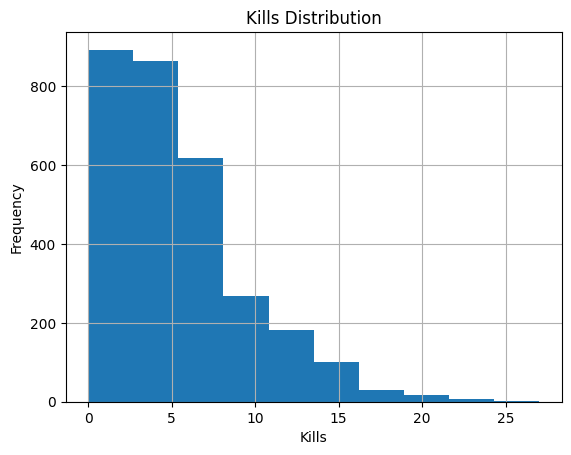

In [31]:
df["kills"].hist()
plt.title("Kills Distribution")
plt.xlabel("Kills")
plt.ylabel("Frequency")
plt.show()

The distribution of kills is right-skewed, indicating that most players achieve a relatively low number of kills, while a smaller number of players achieve very high kill counts.

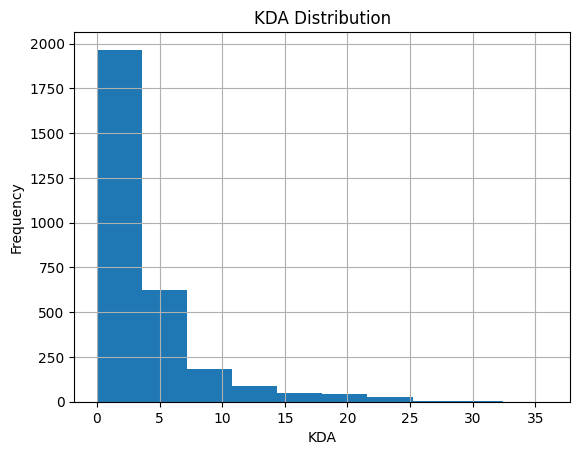

In [32]:
df["kda"].hist()
plt.title("KDA Distribution")
plt.xlabel("KDA")
plt.ylabel("Frequency")
plt.show()

The KDA distribution shows that most players have moderate performance, with fewer extreme values, suggesting balanced gameplay across matches.

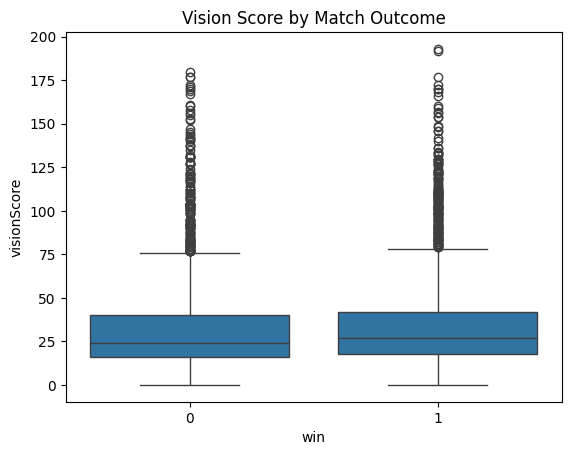

In [33]:
sns.boxplot(x="win", y="visionScore", data=df)
plt.title("Vision Score by Match Outcome")
plt.show()

The boxplot shows that winning matches generally have higher vision scores compared to losing matches, suggesting that map awareness and vision control may contribute to match success.

In [35]:
role_summary = df.groupby("role").agg(
    matches=("win", "count"),
    win_rate=("win", "mean"),
    avg_kda=("kda", "mean"),
    avg_damage=("damage", "mean"),
    avg_vision=("visionScore", "mean")
).sort_values("win_rate", ascending=False)

role_summary

,matches,win_rate,avg_kda,avg_damage,avg_vision
role,,,,,
BOTTOM,596,0.5,3.564933,25135.073826,20.926174
JUNGLE,596,0.5,4.798329,20514.234899,30.406040
MIDDLE,596,0.5,3.674689,22625.208054,21.577181
TOP,596,0.5,2.997573,21734.634228,23.496644
UTILITY,596,0.5,4.241855,10776.802013,83.964765


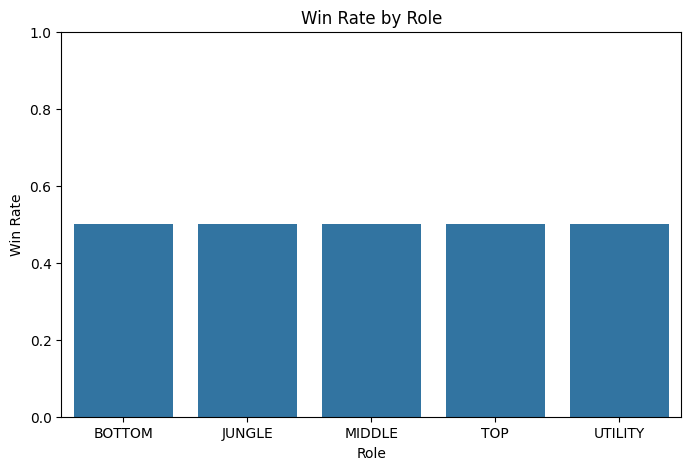

In [36]:
plt.figure(figsize=(8, 5))
sns.barplot(data=role_summary.reset_index(), x="role", y="win_rate")
plt.title("Win Rate by Role")
plt.xlabel("Role")
plt.ylabel("Win Rate")
plt.ylim(0, 1)
plt.show()

Role-based EDA shows whether match outcome differs across roles. This helps identify whether some roles are associated with higher win rates, average KDA, damage, or vision score.

In [37]:
champion_summary = df.groupby("champion").agg(
    matches=("win", "count"),
    win_rate=("win", "mean"),
    avg_kda=("kda", "mean"),
    avg_damage=("damage", "mean"),
    avg_vision=("visionScore", "mean")
).sort_values("matches", ascending=False)

champion_summary.head(15)

,matches,win_rate,avg_kda,avg_damage,avg_vision
champion,,,,,
Ezreal,101,0.574257,4.173126,30965.227723,20.534653
Aurora,69,0.434783,3.266514,24661.579710,24.318841
Jayce,69,0.521739,3.201113,29339.565217,30.594203
Yunara,66,0.484848,3.506386,24753.939394,21.242424
Lulu,61,0.409836,4.065801,8129.000000,71.409836
Karma,59,0.508475,3.816003,10229.694915,89.440678
Anivia,59,0.610169,5.600336,18163.033898,51.983051
Bard,53,0.547170,4.438359,13071.113208,104.886792
Ambessa,49,0.551020,3.245870,21414.612245,26.326531


In [38]:
champion_summary_filtered = champion_summary[champion_summary["matches"] >= 5]

champion_summary_filtered.sort_values("win_rate", ascending=False).head(10)

,matches,win_rate,avg_kda,avg_damage,avg_vision
champion,,,,,
Elise,8,0.875000,6.482486,24151.625000,60.750000
Zilean,7,0.857143,5.380952,4793.714286,29.857143
MonkeyKing,5,0.800000,8.666667,18980.200000,44.200000
Kayle,8,0.750000,2.414583,22319.500000,20.625000
Diana,8,0.750000,7.504167,21938.625000,29.500000
Gwen,8,0.750000,2.134821,25939.375000,24.750000
Hwei,17,0.705882,7.564706,23609.411765,31.705882
Poppy,10,0.700000,4.790000,15726.700000,59.600000
KogMaw,13,0.692308,2.928386,32216.000000,20.769231


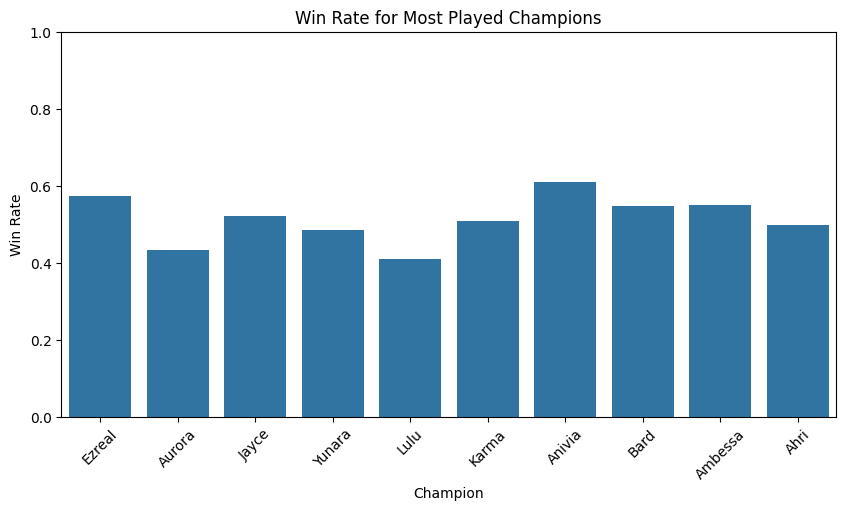

In [39]:
top_champs = champion_summary_filtered.sort_values("matches", ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=top_champs, x="champion", y="win_rate")
plt.title("Win Rate for Most Played Champions")
plt.xlabel("Champion")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

Champion-level analysis is important because champion choice may affect performance metrics and match outcome. To avoid misleading conclusions, champions with very few matches were filtered out.

In [40]:
df.groupby("win")[["damage", "damage_per_min"]].agg(["count", "mean", "median", "std"])

damage                                      damage_per_min              \
     count          mean   median           std          count        mean   
win                                                                          
0     1490  18456.283221  16067.0  11010.445818           1490  670.058025   
1     1490  21858.097987  20376.5  12181.266482           1490  806.053380   

                             
         median         std  
win                          
0    636.701893  307.041633  
1    792.402907  362.638630

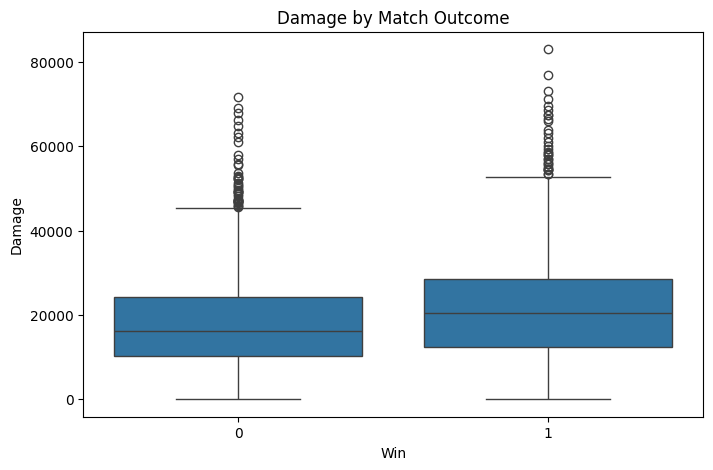

In [41]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="win", y="damage")
plt.title("Damage by Match Outcome")
plt.xlabel("Win")
plt.ylabel("Damage")
plt.show()

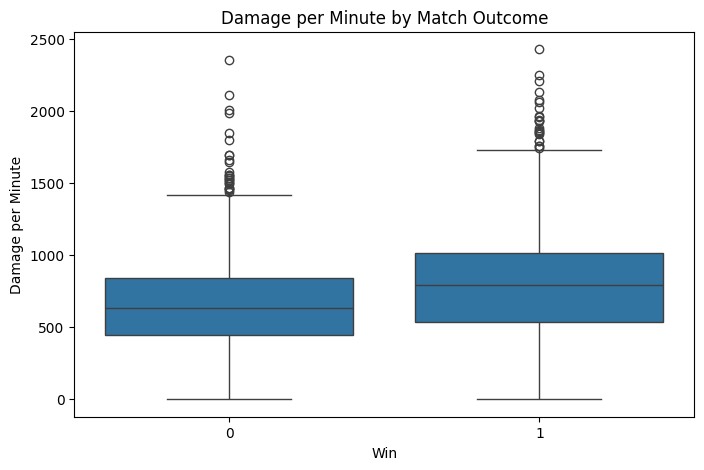

In [42]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="win", y="damage_per_min")
plt.title("Damage per Minute by Match Outcome")
plt.xlabel("Win")
plt.ylabel("Damage per Minute")
plt.show()

Damage and damage-per-minute allow us to compare offensive contribution between wins and losses. Per-minute features are especially useful because raw damage can be affected by match duration.

In [46]:
[col for col in df.columns if "per" in col.lower() or "min" in col.lower()]

['cs_per_min', 'damage_per_min', 'vision_per_min']

In [47]:
per_min_cols = [col for col in ["damage_per_min", "vision_per_min", "cs_per_min"] if col in df.columns]

df[per_min_cols].describe()

,damage_per_min,vision_per_min,cs_per_min
count,2980.000000,2980.000000,2980.000000
mean,738.055703,1.321604,6.434976
std,342.750654,0.978313,2.935295
min,0.000000,0.000000,0.000000
25%,481.713364,0.704941,5.826596
50%,701.688262,0.951821,7.422970
75%,942.704057,1.413822,8.429152
max,2431.056818,5.170557,11.534626


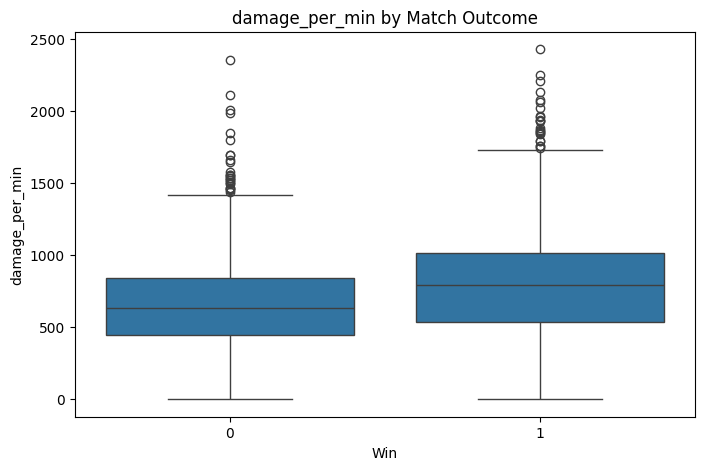

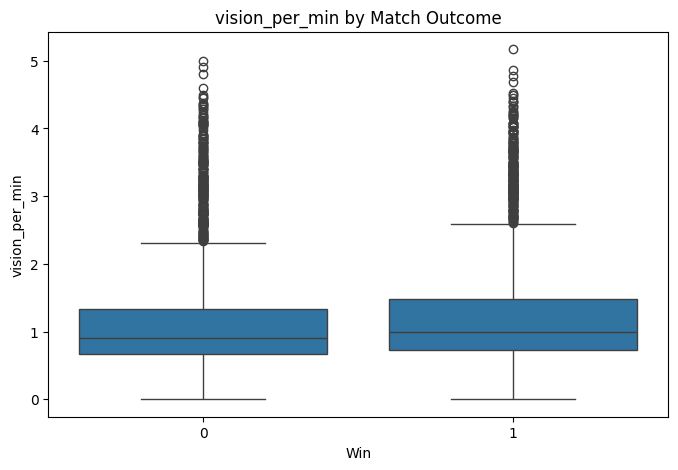

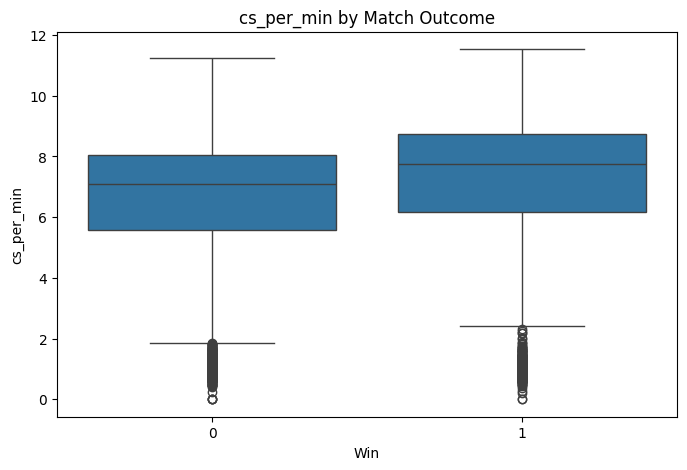

In [48]:
for col in per_min_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="win", y=col)
    plt.title(f"{col} by Match Outcome")
    plt.xlabel("Win")
    plt.ylabel(col)
    plt.show()

Per-minute variables were already included in the dataset. I used these features instead of raw totals because raw damage, vision score, and CS can be affected by match duration. Per-minute features provide fairer comparisons across matches with different lengths.

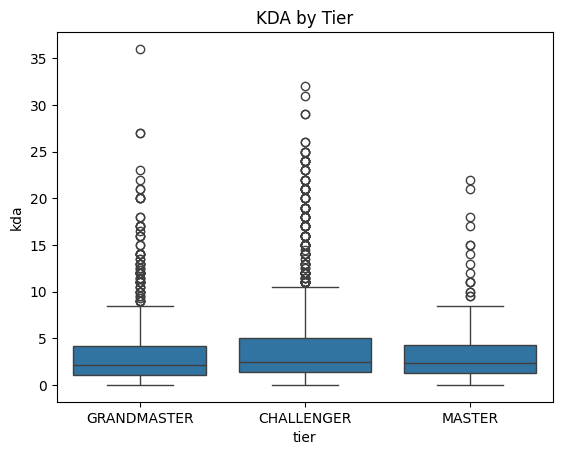

In [9]:
sns.boxplot(x="tier", y="kda", data=df)
plt.title("KDA by Tier")
plt.show()

Players in winning matches tend to deal more damage on average, indicating a strong relationship between damage output and match outcome.

In [10]:
win_vs = df[df["win"] == 1]["visionScore"].dropna()
loss_vs = df[df["win"] == 0]["visionScore"].dropna()

t_stat, p_value = ttest_ind(win_vs, loss_vs)
print(t_stat, p_value)

2.247916104584022 0.02465442255558351


Since the p-value is less than 0.05, we reject the null hypothesis. 
This indicates that there is a statistically significant difference in vision scores between winning and losing matches.

Specifically, winning matches tend to have higher vision scores, suggesting that vision control plays an important role in match success.

In [11]:
table = pd.crosstab(df["tier"], df["win"])
chi2, p, dof, expected = chi2_contingency(table)
print(chi2, p)

11.177117469064669 0.0037404149125206984


Since the p-value is less than 0.05, we reject the null hypothesis. 
This suggests that match outcome is not independent of player tier.

In other words, a player's tier is significantly associated with match success, indicating that higher-ranked players tend to perform better.

## Conclusion

In this analysis, I examined the relationship between gameplay performance metrics and match outcomes in League of Legends.

The results suggest that variables such as vision score and damage are associated with match success. In particular, higher vision scores tend to be observed in winning matches.

Statistical hypothesis testing was conducted to validate these observations. The results indicate that some performance metrics have a statistically significant relationship with match outcomes.

Overall, the findings highlight the importance of in-game performance metrics in determining match success.